In [112]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

#https://www.kaggle.com/datasets/salvatorerastelli/spotify-and-youtube
df = pd.read_csv("Spotify_Youtube.csv")

"""mask = df['Artist'].str.contains("pitbull", case = False, na = False)
t = df[mask]
t"""

'mask = df[\'Artist\'].str.contains("pitbull", case = False, na = False)\nt = df[mask]\nt'

Hypothesis 1 (Predictive Modeling – Regression)

H1: Audio features (danceability, energy, valence, tempo, loudness, etc.) and YouTube metrics (views, likes, comments) significantly predict a track’s Spotify popularity (Stream count).

Analysis Plan:
To test this hypothesis, I will build a multiple linear regression model predicting the variable Stream. Before modeling, I will examine correlations between numerical features and visualize relationships using scatter plots and boxplots. I will also scale variables where necessary. The regression will help identify which features most strongly influence popularity and how well the model explains the variability in stream counts.

Hypothesis 2 (Unsupervised Modeling – Clustering)

H2: Spotify tracks naturally group into distinct clusters based on musical characteristics (danceability, energy, tempo, loudness, acousticness) and YouTube performance metrics.

Analysis Plan:
To test this hypothesis, I will perform K-Means clustering using selected audio and engagement features. Before clustering, I will standardize variables and test several values of k to identify the ideal number of clusters using the elbow method. Finally, I will interpret the resulting clusters by comparing average feature values within each cluster to determine meaningful patterns in track types

In [113]:
df.head()

,Unnamed: 0,Artist,Url_spotify,Track,Album,Album_type,Uri,Danceability,Energy,Key,...,Url_youtube,Title,Channel,Views,Likes,Comments,Description,Licensed,official_video,Stream
0,0,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Feel Good Inc.,Demon Days,album,spotify:track:0d28khcov6AiegSCpG5TuT,0.818,0.705,6.0,...,https://www.youtube.com/watch?v=HyHNuVaZJ-k,Gorillaz - Feel Good Inc. (Official Video),Gorillaz,693555221.0,6220896.0,169907.0,Official HD Video for Gorillaz' fantastic trac...,True,True,1.040235e+09
1,1,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Rhinestone Eyes,Plastic Beach,album,spotify:track:1foMv2HQwfQ2vntFf9HFeG,0.676,0.703,8.0,...,https://www.youtube.com/watch?v=yYDmaexVHic,Gorillaz - Rhinestone Eyes [Storyboard Film] (...,Gorillaz,72011645.0,1079128.0,31003.0,The official video for Gorillaz - Rhinestone E...,True,True,3.100837e+08
2,2,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,New Gold (feat. Tame Impala and Bootie Brown),New Gold (feat. Tame Impala and Bootie Brown),single,spotify:track:64dLd6rVqDLtkXFYrEUHIU,0.695,0.923,1.0,...,https://www.youtube.com/watch?v=qJa-VFwPpYA,Gorillaz - New Gold ft. Tame Impala & Bootie B...,Gorillaz,8435055.0,282142.0,7399.0,Gorillaz - New Gold ft. Tame Impala & Bootie B...,True,True,6.306347e+07
3,3,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,On Melancholy Hill,Plastic Beach,album,spotify:track:0q6LuUqGLUiCPP1cbdwFs3,0.689,0.739,2.0,...,https://www.youtube.com/watch?v=04mfKJWDSzI,Gorillaz - On Melancholy Hill (Official Video),Gorillaz,211754952.0,1788577.0,55229.0,Follow Gorillaz online:\nhttp://gorillaz.com \...,True,True,4.346636e+08
4,4,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Clint Eastwood,Gorillaz,album,spotify:track:7yMiX7n9SBvadzox8T5jzT,0.663,0.694,10.0,...,https://www.youtube.com/watch?v=1V_xRb0x9aw,Gorillaz - Clint Eastwood (Official Video),Gorillaz,618480958.0,6197318.0,155930.0,The official music video for Gorillaz - Clint ...,True,True,6.172597e+08


In [114]:
df.describe()

,Unnamed: 0,Danceability,Energy,Key,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Duration_ms,Views,Likes,Comments,Stream
count,20718.000000,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,2.071600e+04,2.024800e+04,2.017700e+04,2.014900e+04,2.014200e+04
mean,10358.500000,0.619777,0.635250,5.300348,-7.671680,0.096456,0.291535,0.055962,0.193521,0.529853,120.638340,2.247176e+05,9.393782e+07,6.633411e+05,2.751899e+04,1.359422e+08
std,5980.915774,0.165272,0.214147,3.576449,4.632749,0.111960,0.286299,0.193262,0.168531,0.245441,29.579018,1.247905e+05,2.746443e+08,1.789324e+06,1.932347e+05,2.441321e+08
min,0.000000,0.000000,0.000020,0.000000,-46.251000,0.000000,0.000001,0.000000,0.014500,0.000000,0.000000,3.098500e+04,0.000000e+00,0.000000e+00,0.000000e+00,6.574000e+03
25%,5179.250000,0.518000,0.507000,2.000000,-8.858000,0.035700,0.045200,0.000000,0.094100,0.339000,97.002000,1.800095e+05,1.826002e+06,2.158100e+04,5.090000e+02,1.767486e+07
50%,10358.500000,0.637000,0.666000,5.000000,-6.536000,0.050500,0.193000,0.000002,0.125000,0.537000,119.965000,2.132845e+05,1.450110e+07,1.244810e+05,3.277000e+03,4.968298e+07
75%,15537.750000,0.740250,0.798000,8.000000,-4.931000,0.103000,0.477250,0.000463,0.237000,0.726250,139.935000,2.524430e+05,7.039975e+07,5.221480e+05,1.436000e+04,1.383581e+08
max,20717.000000,0.975000,1.000000,11.000000,0.920000,0.964000,0.996000,1.000000,1.000000,0.993000,243.372000,4.676058e+06,8.079649e+09,5.078865e+07,1.608314e+07,3.386520e+09


In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20718 entries, 0 to 20717
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        20718 non-null  int64  
 1   Artist            20718 non-null  object 
 2   Url_spotify       20718 non-null  object 
 3   Track             20718 non-null  object 
 4   Album             20718 non-null  object 
 5   Album_type        20718 non-null  object 
 6   Uri               20718 non-null  object 
 7   Danceability      20716 non-null  float64
 8   Energy            20716 non-null  float64
 9   Key               20716 non-null  float64
 10  Loudness          20716 non-null  float64
 11  Speechiness       20716 non-null  float64
 12  Acousticness      20716 non-null  float64
 13  Instrumentalness  20716 non-null  float64
 14  Liveness          20716 non-null  float64
 15  Valence           20716 non-null  float64
 16  Tempo             20716 non-null  float6

In [116]:
# Removing all non essential attributes. Artist and Track are kept for possible identification,
# Stream is kept as the target variable, and everything else is a feature variable
# Removed attributes include those that are not useful for analysis or relate to youtube statistics
df = df[['Danceability', 'Energy', 'Key', 'Loudness', 'Speechiness', 'Acousticness',
          'Instrumentalness', 'Liveness', 'Valence', 'Tempo', 'Duration_ms', 'Stream']]
# Removing all na values in the data
print(df.isnull().sum())
df = df.dropna()
print(df.isnull().sum())

Danceability          2
Energy                2
Key                   2
Loudness              2
Speechiness           2
Acousticness          2
Instrumentalness      2
Liveness              2
Valence               2
Tempo                 2
Duration_ms           2
Stream              576
dtype: int64
Danceability        0
Energy              0
Key                 0
Loudness            0
Speechiness         0
Acousticness        0
Instrumentalness    0
Liveness            0
Valence             0
Tempo               0
Duration_ms         0
Stream              0
dtype: int64


In [117]:
# Removing outliers and creating a new dataframe to hold this info
q1 = df.quantile(0.25)
q3 = df.quantile(0.75)
iqr = q3 - q1
df_no_outliers = df[~ ((df < (q1 - 1.5 * iqr)) | (df > (q3 + 1.5 * iqr))).any(axis = 1)]
print(df_no_outliers.shape)
print(df.shape)

(10343, 12)
(20140, 12)


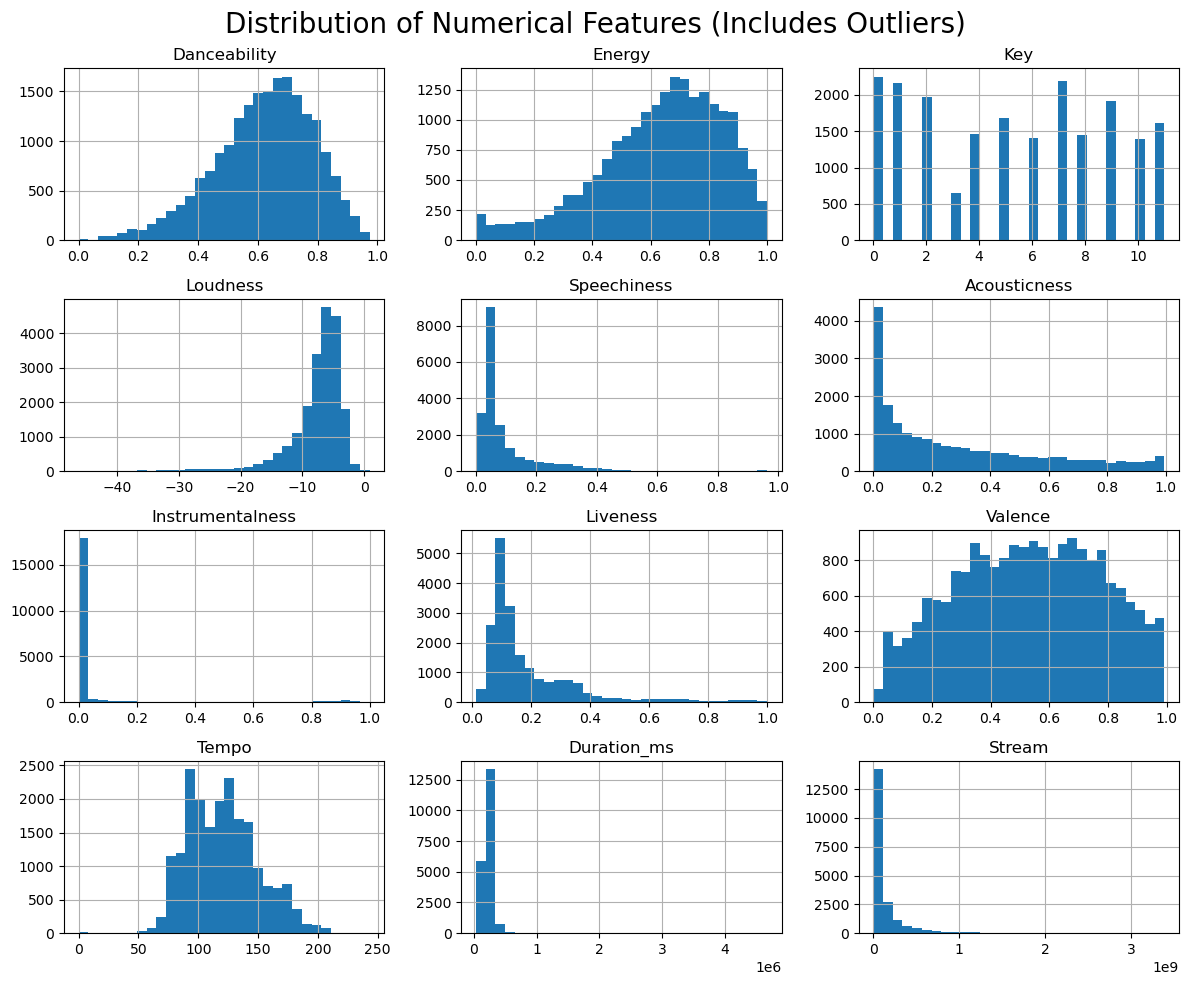

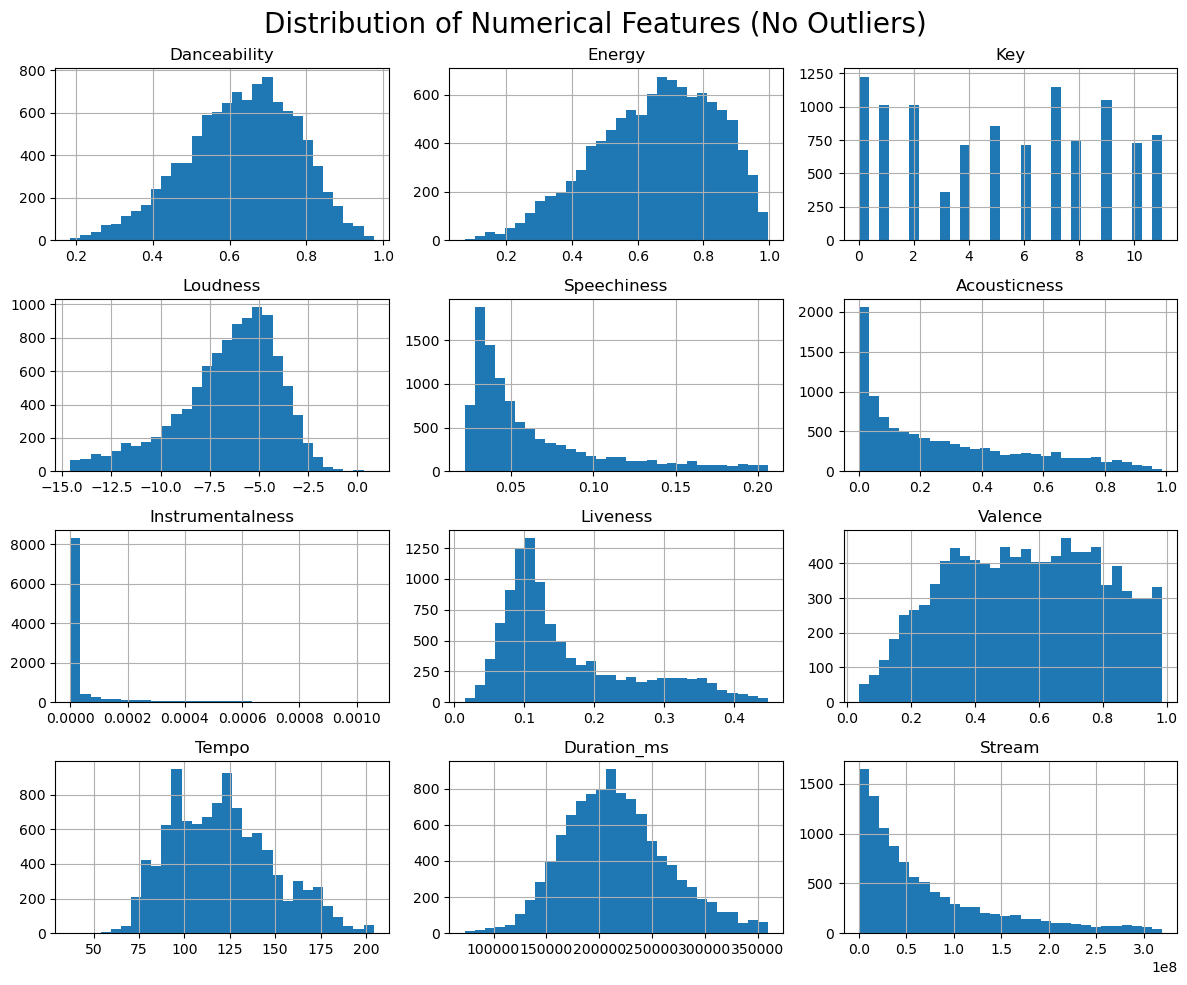

In [118]:
# Displays histograms of all numerical features in the dataset (Includes Outliers)
df.hist(bins=  30, figsize = (12, 10))
plt.suptitle("Distribution of Numerical Features (Includes Outliers)", fontsize = 20)
plt.tight_layout()
plt.show()

# Displays histograms of all numerical features in the dataset (No Outliers)
df_no_outliers.hist(bins=  30, figsize = (12, 10))
plt.suptitle("Distribution of Numerical Features (No Outliers)", fontsize = 20)
plt.tight_layout()
plt.show()

# DURATION_MS AND STREAM ARE HEAVILY AFFECTED BY OUTLIERS

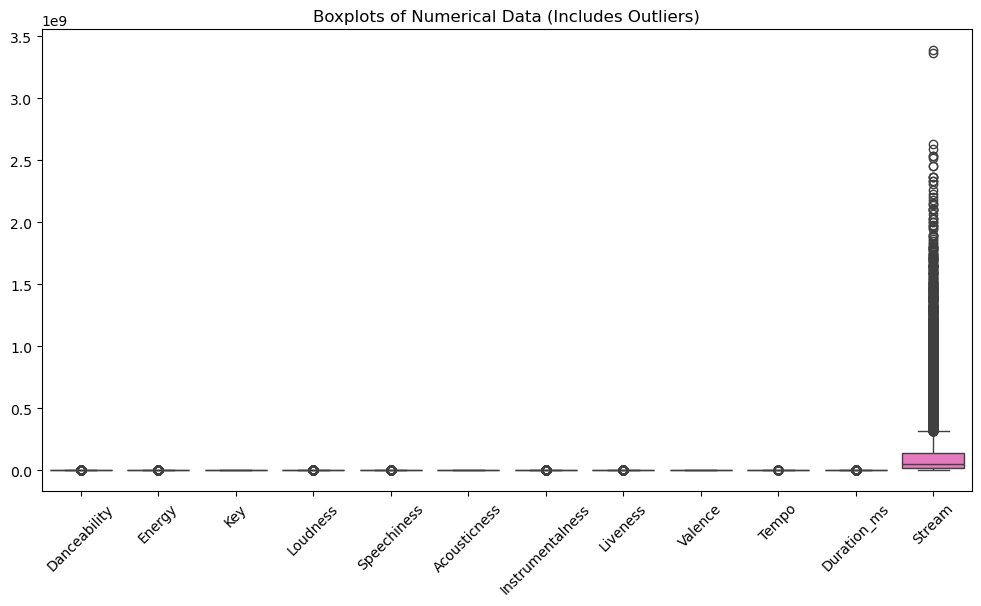

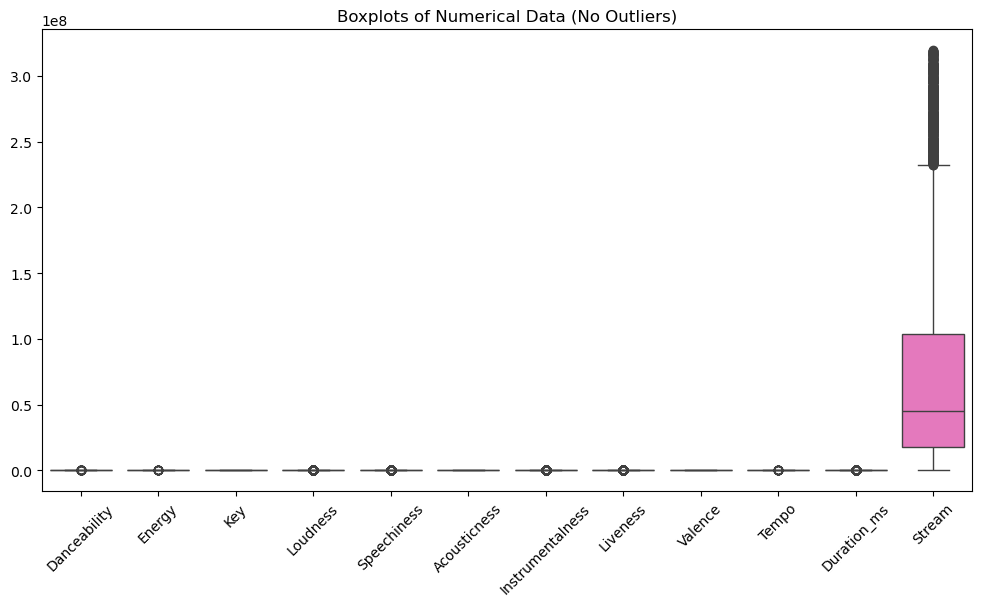

In [119]:
# Creating boxplot for the provided metrics (Includes outliers)
# Not very useful since everything is on such a different scale. Removing a column only creates a new
# "large" metric with everything else still not visible. This applies to both with and wihout outliers
plt.figure(figsize = (12, 6))
sns.boxplot(data = df)
plt.xticks(rotation = 45)
plt.title("Boxplots of Numerical Data (Includes Outliers)")
plt.show()

# Creating boxplot for the provided metrics (No Outliers)
plt.figure(figsize = (12, 6))
sns.boxplot(data = df_no_outliers)
plt.xticks(rotation = 45)
plt.title("Boxplots of Numerical Data (No Outliers)")
plt.show()

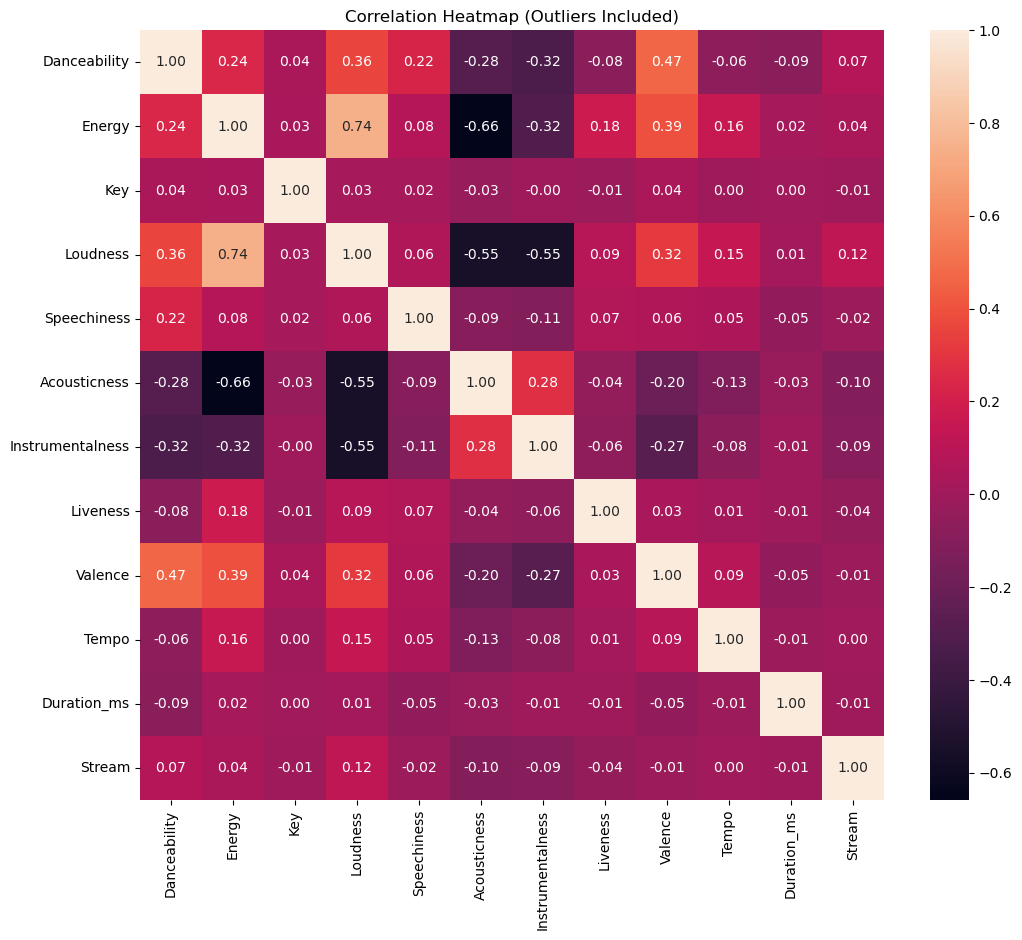

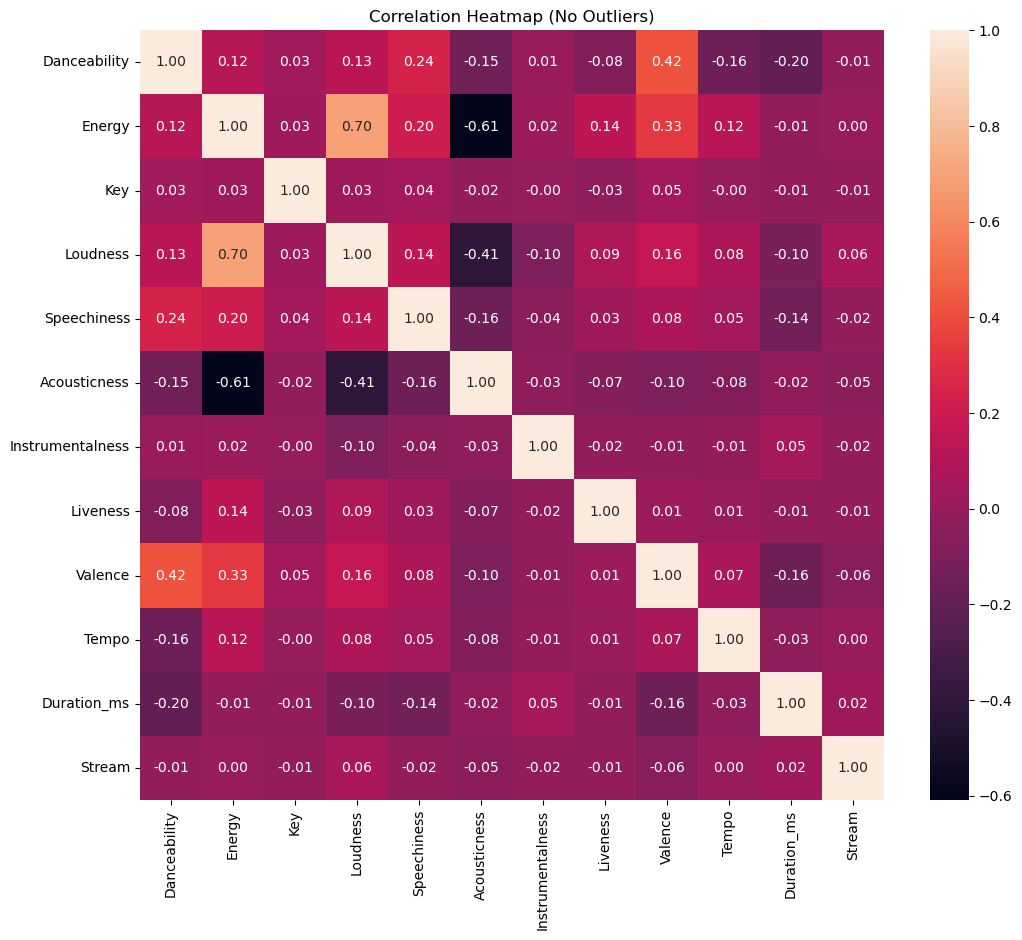

In [120]:
# Correlation Heatmap (Outliers Included)
plt.figure(figsize = (12, 10))
sns.heatmap(df.corr(), annot = True, fmt = ".2f")
plt.title("Correlation Heatmap (Outliers Included)")
plt.show()

# Correlation Heatmap (No Outliers)
plt.figure(figsize = (12, 10))
sns.heatmap(df_no_outliers.corr(), annot = True, fmt = ".2f")
plt.title("Correlation Heatmap (No Outliers)")
plt.show()

# REMOVING OUTLIERS DECREASES INTENSITY IN MANY DIAGONAL POSITIONS

In [121]:
# Function Declarations

# Linear Regression Model
def linearModel(data):
    featureNames = ['Danceability', 'Energy', 'Key', 'Loudness', 'Speechiness', 'Acousticness',
          'Instrumentalness', 'Liveness', 'Valence', 'Tempo', 'Duration_ms']
    features = data[featureNames]
    target = data[['Stream']]
    common_index = features.index.intersection(target.index)
    modelX = features.loc[common_index]
    modelY = target.loc[common_index]
    
    # Training/Testing data
    trainingX, testingX, trainingY, testingY = train_test_split(
        modelX, modelY, test_size = 0.2, random_state = 42
    )

    # Linear Model
    linMod = LinearRegression()
    linMod.fit(trainingX, trainingY)
    predictionDataLinMod = linMod.predict(testingX)

    # Performance metrics
    print("Regression R²:", r2_score(testingY, predictionDataLinMod))
    print("RMSE:", np.sqrt(mean_squared_error(testingY, predictionDataLinMod)))

    # Feature coefficients
    coef_df = pd.DataFrame({
        "Feature": featureNames,
        "Coefficient": linMod.coef_.flatten()
    })
    print(coef_df)

    # Plotting actual vs predicted stream values in regression model
    plt.figure(figsize = (8,6))
    plt.scatter(testingY, predictionDataLinMod, alpha = 0.6)
    plt.xlabel("Actual Stream Values")
    plt.ylabel("Predicted Stream Values")
    plt.title("Predicted vs Actual: Linear Regression Model")
    plt.plot([testingY.min(), testingY.max()], [testingY.min(), testingY.max()], color = 'black')
    plt.show()

    # Plotting residuals
    residuals = testingY.values.flatten() - predictionDataLinMod.flatten()
    plt.figure(figsize = (8,6))
    plt.scatter(predictionDataLinMod, residuals, alpha = 0.6)
    plt.axhline(y = 0, color = 'black')
    plt.xlabel("Predicted Stream Values")

# K Means Clustering Model
def clusteringModel(data, nClusters):
    # Fixes copy warning from Pandas
    data = data.copy()

    featureNames = ['Danceability', 'Energy', 'Key', 'Loudness', 'Speechiness', 'Acousticness',
          'Instrumentalness', 'Liveness', 'Valence', 'Tempo', 'Duration_ms']
    features = data[featureNames]
    target = data[['Stream']]
    common_index = features.index.intersection(target.index)
    modelX = features.loc[common_index]

    # Standardize data
    scaler = StandardScaler()
    modelXScaled = scaler.fit_transform(modelX)

    # Elbow Method
    inertia_scores = []
    k_values = range(2, 30)
    for k in k_values:
        kmeans = KMeans(n_clusters = k, random_state = 42)
        kmeans.fit(modelXScaled)
        inertia_scores.append(kmeans.inertia_)

    # Plotting elbow method to find the bend
    plt.figure(figsize = (8,6))
    plt.plot(k_values, inertia_scores)
    plt.xlabel("k")
    plt.ylabel("Inertia")
    plt.title("Elbow Method for Choosing k")
    plt.show()

    # Use k from elbow
    kmeans = KMeans(n_clusters = nClusters, random_state = 42)
    clusters = kmeans.fit_predict(modelXScaled)
    data["Cluster"] = clusters
    print(data.groupby("Cluster")[featureNames].mean())

    # Reduce to 2 principal components for visualization
    pca = PCA(n_components = 2)
    pcaData = pca.fit_transform(modelXScaled)
    data["PCA1"] = pcaData[:,0]
    data["PCA2"] = pcaData[:,1]
    plt.figure(figsize=(8,6))
    sns.scatterplot(data = data, x = "PCA1", y = "PCA2", hue = "Cluster", palette = "tab10", alpha = 0.75)
    plt.title("K-Means Clusters Visualized with PCA")
    plt.show()

    """sns.pairplot(
        data,
        #    vars=modelX -> it timed out so i limited to these variables,
        vars= ["Danceability", "Energy", "Valence", "Tempo"],
        hue="Cluster",
        palette="tab10"
    )
    plt.show()"""



Regression R²: 0.03569393579621283
RMSE: 236493915.52297068
             Feature   Coefficient
0       Danceability  5.360907e+07
1             Energy -1.348679e+08
2                Key -6.811387e+05
3           Loudness  7.745332e+06
4        Speechiness -6.443546e+07
5       Acousticness -8.023781e+07
6   Instrumentalness -3.447632e+07
7           Liveness -4.703670e+07
8            Valence -5.212794e+07
9              Tempo  3.163492e+04
10       Duration_ms -2.681276e+01


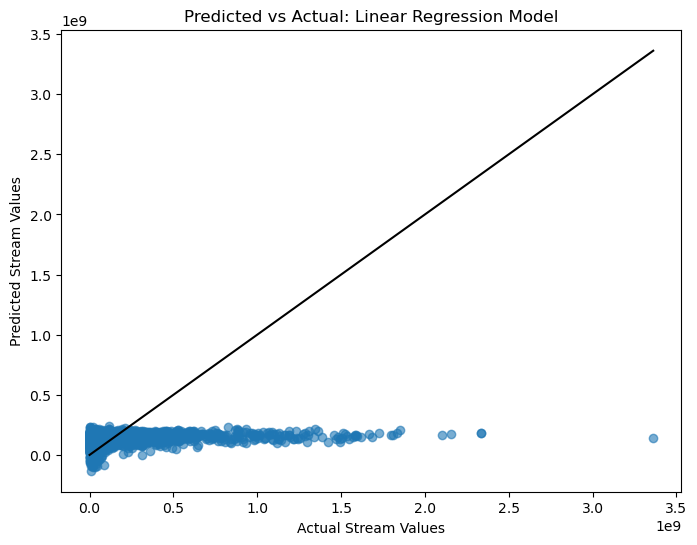

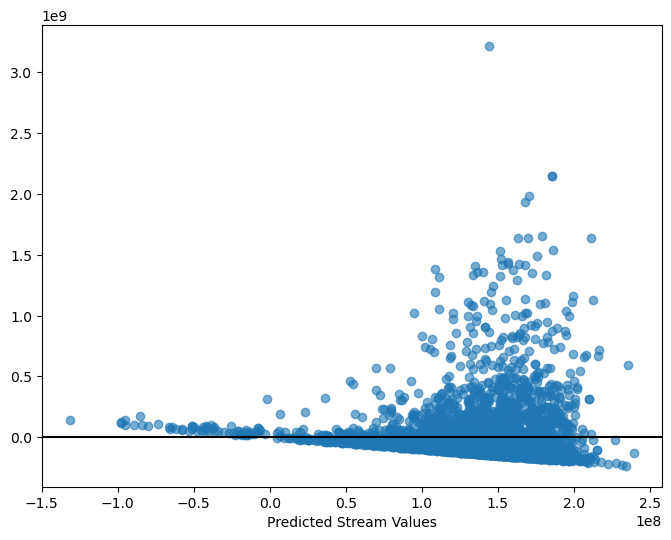

In [122]:
linearModel(df)

Regression R²: 0.01042358555998446
RMSE: 72648717.56669255
             Feature   Coefficient
0       Danceability  2.145356e+06
1             Energy -3.699147e+07
2                Key -1.096154e+05
3           Loudness  3.198096e+06
4        Speechiness -2.274347e+07
5       Acousticness -2.039409e+07
6   Instrumentalness -1.247772e+09
7           Liveness -1.510410e+07
8            Valence -1.380645e+07
9              Tempo -4.310767e+03
10       Duration_ms  2.427288e+01


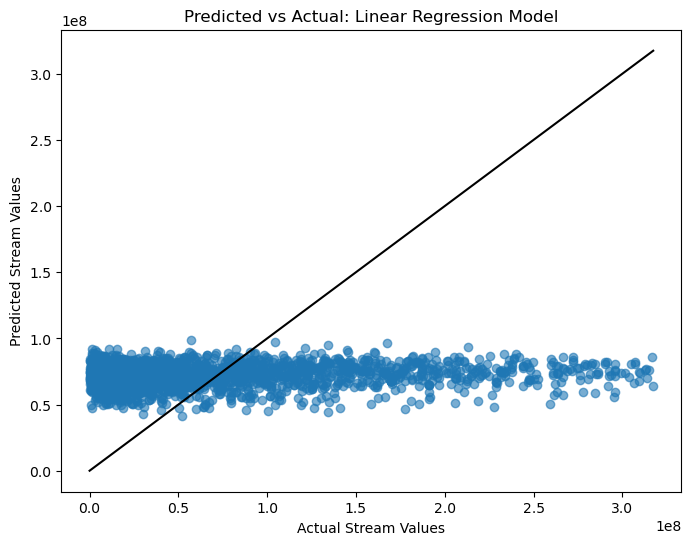

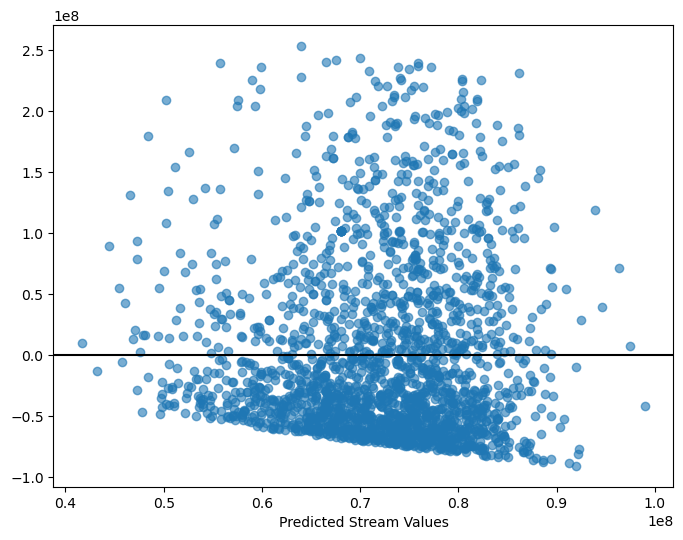

In [123]:
linearModel(df_no_outliers)

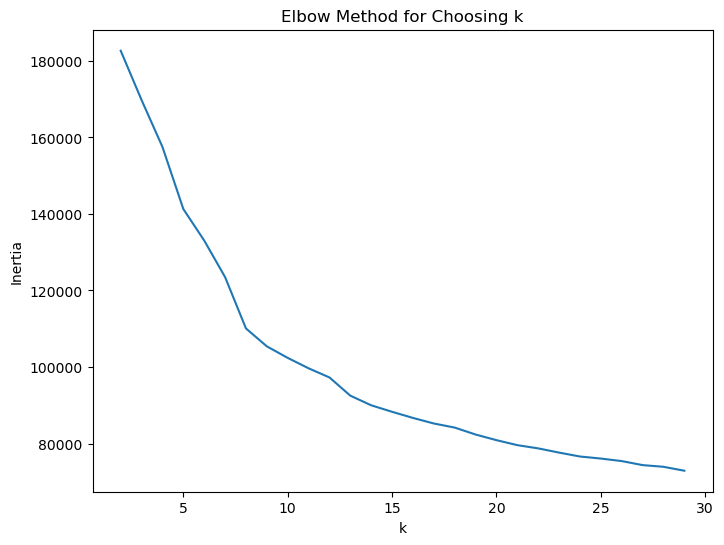

         Danceability    Energy       Key   Loudness  Speechiness  \
Cluster                                                             
0            0.588539  0.735524  5.247974  -6.332130     0.094360   
1            0.532200  0.378924  4.978704 -10.740299     0.046658   
2            0.709792  0.709531  1.982183  -6.206342     0.072958   
3            0.321905  0.184588  5.002497 -22.614497     0.045916   
4            0.714942  0.632290  5.416970  -7.255781     0.353352   
5            0.493990  0.743664  5.110666  -5.870882     0.066097   
6            0.489392  0.827417  5.750000  -5.798833     0.089708   
7            0.709932  0.713709  8.702948  -6.148980     0.076729   

         Acousticness  Instrumentalness  Liveness   Valence       Tempo  \
Cluster                                                                   
0            0.275032          0.020310  0.697421  0.568994  122.106379   
1            0.646740          0.020955  0.146518  0.371081  112.646963   
2        

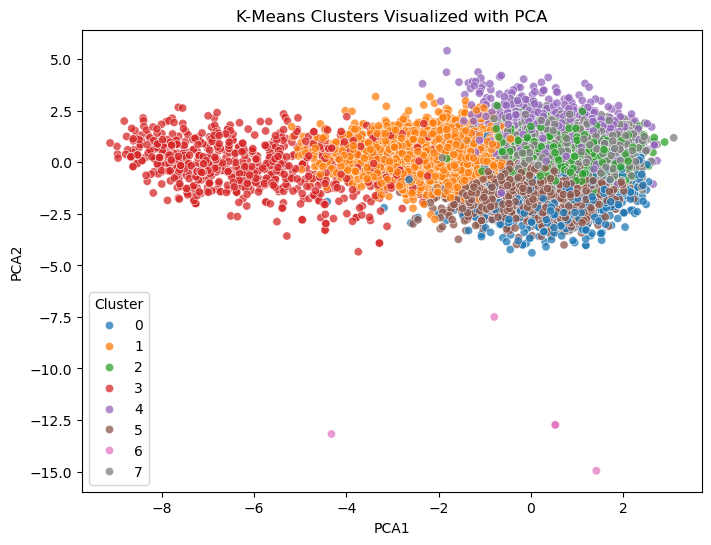

In [ ]:
# nClusters = 8 because of elbow bend location
clusteringModel(df, 8)

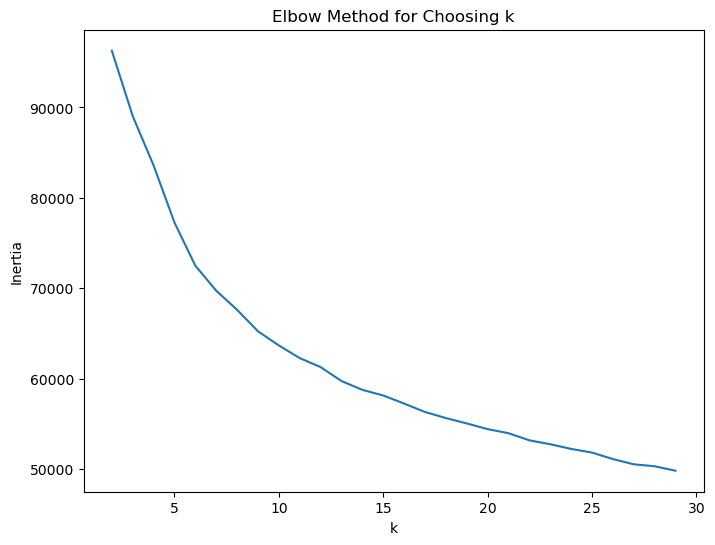

         Danceability    Energy       Key  Loudness  Speechiness  \
Cluster                                                            
0            0.648952  0.674729  5.073643 -7.249186     0.055519   
1            0.719093  0.691631  5.858255 -6.083637     0.151699   
2            0.721236  0.719349  5.575157 -5.701707     0.052726   
3            0.637193  0.769418  5.062219 -5.338711     0.061835   
4            0.554514  0.412109  4.880392 -9.567126     0.042759   
5            0.519348  0.698663  5.260386 -5.868259     0.049186   

         Acousticness  Instrumentalness  Liveness   Valence       Tempo  \
Cluster                                                                   
0            0.232494          0.000691  0.150586  0.557902  119.698436   
1            0.214117          0.000026  0.143027  0.573254  120.370030   
2            0.216148          0.000025  0.108858  0.733389  117.903193   
3            0.176588          0.000026  0.321700  0.634511  124.445661   
4    

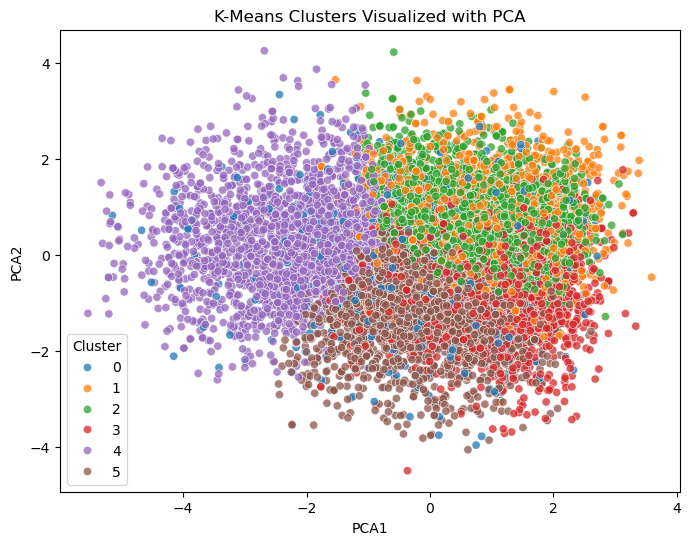

In [125]:
# nClusters = 6 because of elbow bend location
clusteringModel(df_no_outliers, 6)